# 0. 라이브러리 불러오기 및 전체 데이터 로드


In [1]:
import pandas as pd
import numpy as np
import platform
import matplotlib.pyplot as plt #색깔 맞추기
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 그래프에서 한글이 깨지지 않도록 폰트 설정
os_name = platform.system()

if os_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif os_name == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rc('axes', unicode_minus=False)

print("마스터 데이터 로딩")

df = pd.read_csv('apt_ml_master.csv', encoding='utf-8-sig', low_memory=False)

print("데이터 len")
print("행 개수:", len(df))
print("열 개수:", len(df.columns))

마스터 데이터 로딩
데이터 len
행 개수: 2396830
열 개수: 46


# 1. 전체 데이터의 결측치 현황 확인

이 셀에서는 전체 데이터에서 어떤 컬럼에 결측치가 있는지 먼저 확인.  
결측치는 값이 비어 있는 데이터를 의미.  
예를 들어 어떤 아파트 거래 행에서 `고령화율` 값이 비어 있거나, `aptDong` 값이 비어 있다면 그것이 결측치.

먼저 전체 행의 개수를 `total_rows`에 저장.  
그 다음 `df.isna().sum()`을 사용해서 각 컬럼별 결측치 개수를 계산.  
`isna()`는 값이 비어 있으면 `True`, 비어 있지 않으면 `False`를 반환하고, 여기에 `sum()`을 붙이면 `True`의 개수, 즉 결측치 개수를 세게 됨.

그 다음 결측치가 1개 이상 있는 컬럼만 따로 골라서 표로 정리.  
단순히 결측 개수만 보는 것이 아니라, 전체 데이터 중 몇 퍼센트가 결측인지도 같이 계산.  
이 비율은 `결측 개수 / 전체 행 수 * 100`으로 계산.


=== 결측치 일차 현황 점검 ===
전체 행 수: 2396830


,Column,Missing_Count,Missing_Ratio(%)
0,고령화율,93,0.0039
1,aptDong,25,0.0010


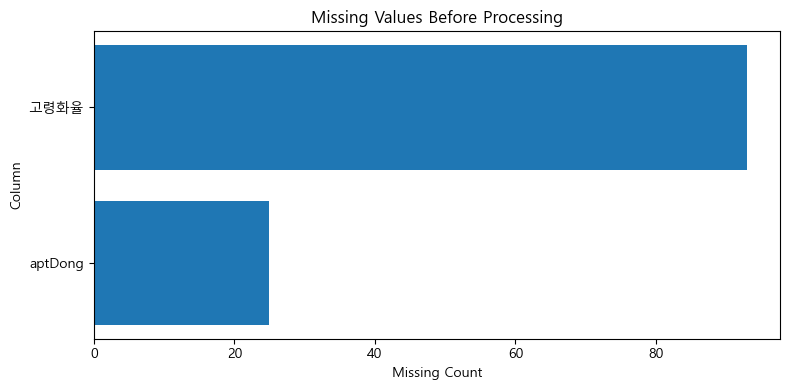

In [2]:
total_rows = len(df)

missing_rows = []

for col in df.columns:
    missing_count = df[col].isna().sum()

    if missing_count > 0:
        missing_ratio = missing_count / total_rows * 100

        missing_rows.append({
            'Column': col,
            'Missing_Count': missing_count,
            'Missing_Ratio(%)': missing_ratio
        })

df_missing_status = pd.DataFrame(missing_rows)

if len(df_missing_status) > 0:
    df_missing_status = df_missing_status.sort_values('Missing_Count', ascending=False)
    df_missing_status = df_missing_status.reset_index(drop=True)

print("=== 결측치 일차 현황 점검 ===")
print("전체 행 수:", total_rows)

if len(df_missing_status) == 0:
    print("결측치 없음")
else:
    display(df_missing_status.round({'Missing_Ratio(%)': 4}))

    plt.figure(figsize=(8, 4))
    plt.barh(df_missing_status['Column'], df_missing_status['Missing_Count'])
    plt.xlabel('Missing Count')
    plt.ylabel('Column')
    plt.title('Missing Values Before Processing')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 2. 두 결측 변수의 상호 연관성 확인

이 단계에서는 `고령화율` 결측과 `aptDong` 결측이 서로 같은 행에서 발생했는지 확인.  
결측치를 처리할 때는 단순히 비어 있는 값을 채우는 것보다, 먼저 왜 비어 있는지 생각하는 과정이 중요.

만약 두 컬럼이 같은 행에서 동시에 결측이라면, 어떤 공통된 원인 때문에 같이 누락되었을 가능성이 있음.  
예를 들어 특정 지역의 데이터가 제대로 병합되지 않았다면, 지역 관련 변수들이 동시에 비어 있을 수 있음.  
반대로 두 결측치가 서로 다른 행에서 발생했다면, 각각 다른 이유로 결측이 생겼다고 보는 것이 더 자연스러움.

그래서 이 셀에서는 두 결측 여부를 `True`와 `False`로 바꾼 뒤, 교차표를 만들어 확인.  
`aptDong`이 결측인 경우와 아닌 경우, 그리고 `고령화율`이 결측인 경우와 아닌 경우를 서로 비교하는 방식.  
이 결과를 보면 두 결측치가 같은 문제에서 나온 것인지, 아니면 별개의 문제인지 판단할 수 있음.

이 분석은 이후 결측치 처리 방향을 정하는 근거.  
같은 원인이라면 한 번에 묶어서 처리할 수 있고, 다른 원인이라면 각각 따로 설명하고 처리하는 것이 더 타당.


In [3]:
print("=== 고령화율과 aptDong 결측치가 겹치는지 확인 ===")

dong_null = df['aptDong'].isna()
aging_null = df['고령화율'].isna()

overlap_matrix = pd.crosstab(dong_null, aging_null)

print("행: aptDong 결측 여부")
print("열: 고령화율 결측 여부")
display(overlap_matrix)

both_null = dong_null & aging_null
overlap_count = both_null.sum()

print("두 컬럼이 동시에 결측인 행 수:", overlap_count)

if overlap_count > 0:
    print("두 결측치가 같은 행에서 함께 나타나는 경우 있음")
else:
    print("두 결측치는 서로 겹치지 않음")

=== 고령화율과 aptDong 결측치가 겹치는지 확인 ===
행: aptDong 결측 여부
열: 고령화율 결측 여부


고령화율,False,True
aptDong,,
False,2396712,93
True,25,0


두 컬럼이 동시에 결측인 행 수: 0
두 결측치는 서로 겹치지 않음


# 3. 군위군 행정구역 개편에 따른 고령화율 결측 원인 확인

이 단계에서는 `고령화율` 결측이 왜 발생했는지 도메인 관점에서 확인.  
여기서 도메인 관점이라는 것은 단순히 코드만 보는 것이 아니라, 실제 행정구역이나 데이터 생성 배경까지 함께 고려하는 것을 의미.

현재 데이터에서 중요한 문제는 군위군.  
군위군은 과거에는 경상북도에 속해 있었지만, 2023년 7월 1일부터 대구광역시로 편입.  
이런 행정구역 변화가 생기면 데이터 병합 과정에서 문제가 발생할 수 있음.

예를 들어 아파트 실거래 데이터는 최신 행정구역 기준으로 군위군을 대구광역시 군위군으로 가지고 있을 수 있음.  
반면 고령화율 데이터는 과거 행정구역 기준으로 경상북도 군위군 코드에 묶여 있을 수 있음.  
이렇게 두 데이터셋의 지역 코드 기준이 다르면, 실제로는 같은 지역인데도 코드가 달라서 병합이 실패할 수 있음.

따라서 이 단계에서는 군위군 관련 데이터만 따로 확인.  
군위군 거래가 몇 건 있는지, 그중 고령화율이 비어 있는 행이 몇 건인지 확인해서 결측 원인이 군위군 행정구역 변경과 관련 있는지 판단.


In [ ]:
print("=== 군위군 결측 데이터 확인 ===")

name_mask = df['SGG_NM'].astype(str).str.contains('군위', na=False)
old_code_mask = df['sggCd'].astype(str).str.startswith('4772')
new_code_mask = df['sggCd'].astype(str).str.startswith('2729')

gunwi_mask = name_mask | old_code_mask | new_code_mask
df_gunwi = df[gunwi_mask]

print("군위군 관련 거래 건수:", len(df_gunwi))
print("군위군 중 고령화율 결측 건수:", df_gunwi['고령화율'].isna().sum())

sample_cols = ['sggCd', 'SGG_NM', 'umdNm', 'dealYear', '고령화율']
sample_cols = [col for col in sample_cols if col in df.columns]

print("군위군 고령화율 결측 샘플")
df_gunwi[df_gunwi['고령화율'].isna()][sample_cols].head(5)

=== 군위군 결측 데이터 확인 ===
군위군 관련 거래 건수: 29932
군위군 중 고령화율 결측 건수: 93
군위군 고령화율 결측 샘플


,sggCd,SGG_NM,umdNm,dealYear,고령화율
540235,27720,군위군,군위읍 동부리,2019,NaN
540236,27720,군위군,군위읍 동부리,2019,NaN
540237,27720,군위군,군위읍 동부리,2019,NaN
540238,27720,군위군,군위읍 동부리,2019,NaN
540239,27720,군위군,군위읍 동부리,2019,NaN


# 4. 원본 고령화 데이터셋을 이용한 고령화율 결측 보정

이 코드에서는 `aging_rate_2019_2023.csv` 파일을 다시 읽어 옴.  
이 파일은 원래 고령화율을 담고 있는 데이터셋이므로, 결측치를 채울 때 가장 먼저 참고해야 하는 자료.  
특히 군위군의 연도별 고령화율을 가져와서, 아파트 거래 데이터의 거래연도와 맞춰 채우는 방식을 사용.

먼저 원본 고령화 데이터에서 군위군에 해당하는 행만 골라냄.  
그 다음 연도별 고령화율을 정리해서 `gunwi_by_year`라는 형태로 저장.  
이렇게 만들어 두면 2019년 거래는 2019년 군위군 고령화율로, 2020년 거래는 2020년 군위군 고령화율로 채우는 방식이 가능.



In [5]:
print("=== 원본 고령화 데이터셋으로 고령화율 결측 보정 ===")

# 처리 전 값을 저장해 두면 나중에 처리 전후 분포를 비교할 수 있음
df_backup_aging = df['고령화율'].copy()

aging_source = pd.read_csv('aging_rate_2019_2023.csv', encoding='utf-8-sig')

aging_source['year'] = pd.to_numeric(aging_source['year'], errors='coerce')
aging_source['고령화율'] = pd.to_numeric(aging_source['고령화율'], errors='coerce')

# 원본 고령화 데이터셋에서 군위군 데이터만 가져옴
gunwi_source = aging_source[aging_source['SGG_NM'].astype(str).str.contains('군위', na=False)]
gunwi_source = gunwi_source.sort_values('year').reset_index(drop=True)

if len(gunwi_source) == 0:
    raise ValueError("원본 고령화 데이터셋에서 군위군 값을 찾지 못함")

print("원본 고령화 데이터셋의 군위군 연도별 고령화율")
display(gunwi_source[['year', 'SGG_NM', 'SGG_CODE', '고령화율']])

# 아파트 데이터에서 군위군으로 볼 수 있는 행을 찾음
name_mask = df['SGG_NM'].astype(str).str.contains('군위', na=False)
old_code_mask = df['sggCd'].astype(str).str.startswith('4772')
new_code_mask = df['sggCd'].astype(str).str.startswith('2729')

gunwi_mask = name_mask | old_code_mask | new_code_mask
missing_aging_mask = df['고령화율'].isna()

target_mask = gunwi_mask & missing_aging_mask

before_null = df['고령화율'].isna().sum()
filled_count = 0

# 결측인 군위군 행을 하나씩 보면서, 거래연도와 같은 고령화율을 찾아 넣음
for index in df[target_mask].index:
    deal_year = df.loc[index, 'dealYear']

    same_year_data = gunwi_source[gunwi_source['year'] == deal_year]

    if len(same_year_data) > 0:
        fill_value = same_year_data.iloc[0]['고령화율']
    else:
        # 같은 연도 값이 없을 때만 원본 데이터셋의 최신 값을 사용
        fill_value = gunwi_source.iloc[-1]['고령화율']

    df.loc[index, '고령화율'] = fill_value
    filled_count = filled_count + 1

after_null = df['고령화율'].isna().sum()

# 원본 지역명과 코드는 그대로 두고, 정규화용 컬럼을 따로 만듦
df['SGG_NM_norm'] = df['SGG_NM']
df['sggCd_norm'] = df['sggCd']

df.loc[gunwi_mask, 'SGG_NM_norm'] = '대구광역시 군위군'
df.loc[gunwi_mask, 'sggCd_norm'] = 27290

print("처리 전 고령화율 결측치:", before_null)
print("군위군 결측치 보정 건수:", filled_count)
print("처리 후 고령화율 결측치:", after_null)

=== 원본 고령화 데이터셋으로 고령화율 결측 보정 ===
원본 고령화 데이터셋의 군위군 연도별 고령화율


,year,SGG_NM,SGG_CODE,고령화율
0,2019,군위군,37310,38.10
1,2020,군위군,37310,39.65
2,2021,군위군,37310,41.59
3,2022,군위군,37310,42.81
4,2023,군위군,22520,44.05


처리 전 고령화율 결측치: 93
군위군 결측치 보정 건수: 93
처리 후 고령화율 결측치: 0


# 5. aptDong 결측 처리

aptDong은 동 이름이 없는 거래가 많고, 가격 예측에서 핵심 수치 변수로 사용하기 어렵기 때문에 별도의 의미 있는 값으로 대체하지 않고 빈 문자열로 정리.

In [6]:
print("aptDong 결측 처리")

before_dong_null = df['aptDong'].isna().sum()

# aptDong의 NaN 값을 빈 문자열로 바꿈
df['aptDong'] = df['aptDong'].fillna('')

after_dong_null = df['aptDong'].isna().sum()

print("aptDong 결측치 개수:", before_dong_null)
print("aptDong 처리 후 결측치 개수:", after_dong_null)

sample_cols = ['SGG_NM', 'umdNm', 'aptNm', 'aptDong']
sample_cols = [col for col in sample_cols if col in df.columns]

print("aptDong 처리")
display(df[sample_cols].head(5))

aptDong 결측 처리
aptDong 결측치 개수: 25
aptDong 처리 후 결측치 개수: 0
aptDong 처리


,SGG_NM,umdNm,aptNm,aptDong
0,종로구,사직동,광화문스페이스본(101동~105동),
1,종로구,평창동,벽산블루밍평창힐스,
2,종로구,창신동,동대문,
3,종로구,평창동,롯데낙천대,
4,종로구,평창동,삼성,


In [7]:
df['aptDong'].value_counts()

aptDong
               2051969
101              27532
102              23640
103              18722
104              13818
                ...   
화북2아파트211            1
동아아파트103동            1
화북2아파트213            1
미듬아뜨리에 103           1
미듬하나로아파트 가동          1
Name: count, Length: 4152, dtype: int64

# 6. 결측 처리 이후 결과 확인

이 단계에서는 앞에서 진행한 결측 처리 결과가 제대로 반영되었는지 확인.  
전처리는 한 번 수행했다고 끝나는 것이 아니라, 처리 전과 처리 후가 어떻게 달라졌는지 반드시 확인.  
그래야 값이 잘못 채워졌거나, 의도하지 않은 변화가 생겼는지 발견할 수 있음.

먼저 `고령화율`과 `aptDong`의 잔여 결측치 개수를 출력.  
여기서 `고령화율`은 원본 고령화 데이터셋을 이용해 보정했기 때문에 결측치가 줄어드는 것이 목표.  
반면 `aptDong`은 강제로 값을 채우지 않기로 했기 때문에 결측치가 남아 있어도 이상한 것이 아님.  
중요한 것은 `aptDong` 결측을 없애는 것이 아니라, 왜 남겨 두었는지 설명할 수 있어야 한다는 것.

그 다음 히스토그램을 사용해서 `고령화율`의 보정 전후 분포를 비교.  
히스토그램은 값이 어떤 구간에 얼마나 많이 분포하는지 보여주는 기본 그래프.  
보정 후 분포가 보정 전 분포와 크게 달라지지 않는다면, 결측 처리로 인해 전체 데이터 구조가 심하게 왜곡되지 않았다고 볼 수 있음.


=== 전처리 최종 확인 ===
고령화율 잔여 결측치: 0
aptDong 잔여 결측치: 0


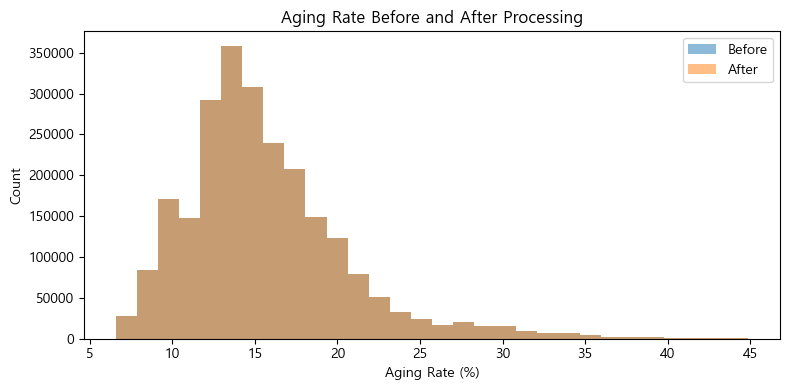

In [8]:
print("=== 전처리 최종 확인 ===")

aging_null_count = df['고령화율'].isna().sum()
dong_null_count = df['aptDong'].isna().sum()

print("고령화율 잔여 결측치:", aging_null_count)
print("aptDong 잔여 결측치:", dong_null_count)

before_aging = df_backup_aging.dropna()
after_aging = df['고령화율'].dropna()

plt.figure(figsize=(8, 4))
plt.hist(before_aging, bins=30, alpha=0.5, label='Before')
plt.hist(after_aging, bins=30, alpha=0.5, label='After')
plt.xlabel('Aging Rate (%)')
plt.ylabel('Count')
plt.title('Aging Rate Before and After Processing')
plt.legend()
plt.tight_layout()
plt.show()

# 7-0. 시군구 컬럼 거래 건수 기준 5단계 분할
- 시군구 컬럼은 단순히 지역 이름을 나타내는 컬럼이지만, 사람들이 특정 지역에 대해 가지고 있는 인식과 실제 데이터 차이를 비교하기 위한 중요한 기준.
- 하지만 시군구 컬럼을 그대로 사용할 시 높은 카디널리티 문제로 모델 학습에 문제가 있을 수 있기 때문에 거래 건수를 기준으로 5단계로 분할하여 유의미한 데이터로 활용.


In [9]:
print("=== 시군구 거래량 기준 5단계 구간화 ===")

sgg_col = 'SGG_NM'

# 1. 시군구별 데이터 개수 계산
sgg_count = df[sgg_col].value_counts()

# 2. 시군구별 거래 건수를 데이터프레임으로 만들기
df_sgg_count = sgg_count.reset_index()
df_sgg_count.columns = [sgg_col, 'sgg_count']

# 3. 거래 건수를 기준으로 5개 구간으로 나누기
labels = ['superlow', 'low', 'middle', 'high', 'superhigh']

df_sgg_count['SGG_level'] = pd.qcut(
    df_sgg_count['sgg_count'],
    q=5,
    labels=labels,
    duplicates='drop'
)

# 4. 원본 df에 시군구 등급 붙이기
df = df.merge(df_sgg_count[[sgg_col, 'sgg_count', 'SGG_level']], on=sgg_col, how='left')

print("시군구 거래량 등급 컬럼을 생성")
display(df_sgg_count.sort_values('sgg_count', ascending=False).head(10))

print("원본 데이터 샘플")
display(df[[sgg_col, 'sgg_count', 'SGG_level']].head())


=== 시군구 거래량 기준 5단계 구간화 ===
시군구 거래량 등급 컬럼을 생성


,SGG_NM,sgg_count,SGG_level
0,북구,111312,superhigh
1,서구,86158,superhigh
2,남구,65405,superhigh
3,동구,48750,superhigh
4,중구,41166,superhigh
5,김해시,36506,superhigh
6,서북구,36476,superhigh
7,평택시,34518,superhigh
8,남양주시,32176,superhigh
9,아산시,31251,superhigh


원본 데이터 샘플


,SGG_NM,sgg_count,SGG_level
0,종로구,2245,low
1,종로구,2245,low
2,종로구,2245,low
3,종로구,2245,low
4,종로구,2245,low


# 7. 높은 카디널리티 컬럼 확인

이 단계에서는 고유값이 너무 많은 범주형 컬럼을 확인.  

높은 카디널리티 컬럼을 모델에 그대로 넣으면 
모델이 아파트 가격의 일반적인 규칙을 배우는 것이 아니라, 특정 아파트 이름이나 특정 주소를 외워 버릴 수 있기 때문.  
이것이 과적합.  
과적합된 모델은 현재 데이터에서는 잘 맞는 것처럼 보일 수 있지만, 새로운 데이터에서는 성능이 떨어질 수 있음.

그래서 이 코드에서는 각 컬럼의 고유값 개수를 계산.  
전체 행 수에 비해 고유값이 얼마나 많은지도 비율로 함께 계산.  
이 결과를 통해 어떤 컬럼이 모델에 넣기 부담스러운 높은 카디널리티 컬럼인지 판단할 수 있음.


=== 높은 카디널리티 컬럼 확인 ===
기준: 고유값 개수 100개 이상


,Column,Unique_Count,Unique_Ratio(%)
0,aptSeq,39925,1.6657
1,aptNm,31667,1.3212
2,jibun,17721,0.7394
3,roadNm,17466,0.7287
4,dealAmount,16915,0.7057
5,estateAgentSggNm,4271,0.1782
6,aptDong,4152,0.1732
7,umdNm,3125,0.1304
8,rgstDate,615,0.0257
9,SGG_NM,221,0.0092


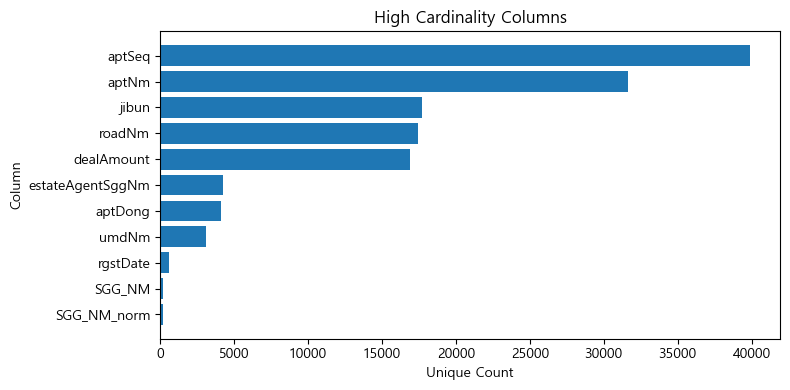

저장된 높은 카디널리티 제외 컬럼:
['aptSeq', 'aptNm', 'jibun', 'roadNm', 'dealAmount', 'estateAgentSggNm', 'aptDong', 'umdNm', 'rgstDate', 'SGG_NM', 'SGG_NM_norm']


In [10]:
threshold = 100

total_rows = len(df)
cardinality_rows = []

# 문자형 컬럼만 대상으로 확인
candidate_cols = df.select_dtypes(include=['object', 'category', 'string']).columns

for col in candidate_cols:
    unique_count = df[col].nunique(dropna=True)
    unique_ratio = unique_count / total_rows * 100

    if unique_count >= threshold:
        cardinality_rows.append({
            'Column': col,
            'Unique_Count': unique_count,
            'Unique_Ratio(%)': unique_ratio
        })

df_card = pd.DataFrame(cardinality_rows)

if len(df_card) > 0:
    df_card = df_card.sort_values('Unique_Count', ascending=False).reset_index(drop=True)

    print("=== 높은 카디널리티 컬럼 확인 ===")
    print("기준: 고유값 개수 100개 이상")
    display(df_card.round({'Unique_Ratio(%)': 4}))

    plt.figure(figsize=(8, 4))
    plt.barh(df_card['Column'], df_card['Unique_Count'])
    plt.xlabel('Unique Count')
    plt.ylabel('Column')
    plt.title('High Cardinality Columns')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

else:
    print("고유값 개수가 100개 이상인 문자형 컬럼 없음")

excluded_high_card_cols = df_card['Column'].tolist()

print("저장된 높은 카디널리티 제외 컬럼:")
print(excluded_high_card_cols)

# 8. 숫자처럼 보이지만 실제로는 식별자인 컬럼 확인

이 단계에서는 숫자형으로 저장되어 있지만 실제 수치 의미는 없는 컬럼들을 확인.  
예를 들어 `sggCd`, `umdCd`, `roadNmCd` 같은 컬럼은 숫자로 되어 있음.  
하지만 이 숫자는 계산을 위한 숫자가 아니라 지역이나 도로를 구분하기 위한 코드.

예를 들어 지역 코드 11110과 11680이 있다고 해서, 11680이 11110보다 더 크거나 더 좋은 지역이라는 뜻은 아님.  
그냥 서로 다른 지역을 구분하기 위한 이름표에 가까움.  
따라서 이런 코드를 그대로 수치형 변수로 모델에 넣으면 모델이 잘못 해석할 수 있음.

이 코드에서는 이런 식별자 컬럼들의 평균, 표준편차, 최솟값, 최댓값 같은 통계량을 출력.  
하지만 이 통계량들은 수학적으로 계산은 가능해도, 도메인적으로는 의미가 거의 없음.  
예를 들어 지역 코드의 평균은 실제 분석에서 해석할 수 있는 값이 아님.

그래프에서는 대표 식별자 코드와 실거래가의 관계를 산점도로 확인.  
이때 데이터가 너무 많기 때문에 일부 샘플만 사용.  
목적은 정확한 예측이 아니라, 코드값이 연속적인 가격 관계를 설명하기에는 부적절하다는 점을 보여주는 것.


=== 식별자 컬럼 자동 확인 ===
자동으로 찾은 식별자 후보 컬럼:
['aptSeq', 'bonbun', 'bubun', 'jibun', 'landCd', 'roadNmBonbun', 'roadNmBubun', 'roadNmCd', 'roadNmSeq', 'roadNmSggCd', 'roadNmbCd', 'sggCd', 'umdCd', 'KOSIS_SGG_CODE', 'LEGAL_SGG_CODE', 'SGG_NM_norm', 'sggCd_norm']


,Column,Dtype,Unique_Count,Unique_Ratio(%),Missing_Count
0,aptSeq,object,39925,1.6657,0
1,roadNmCd,int64,18499,0.7718,0
2,jibun,object,17721,0.7394,0
3,bonbun,int64,2552,0.1065,0
4,roadNmBonbun,int64,1519,0.0634,0
5,bubun,int64,426,0.0178,0
6,umdCd,int64,340,0.0142,0
7,roadNmSggCd,int64,246,0.0103,0
8,sggCd,int64,245,0.0102,0
9,LEGAL_SGG_CODE,int64,245,0.0102,0


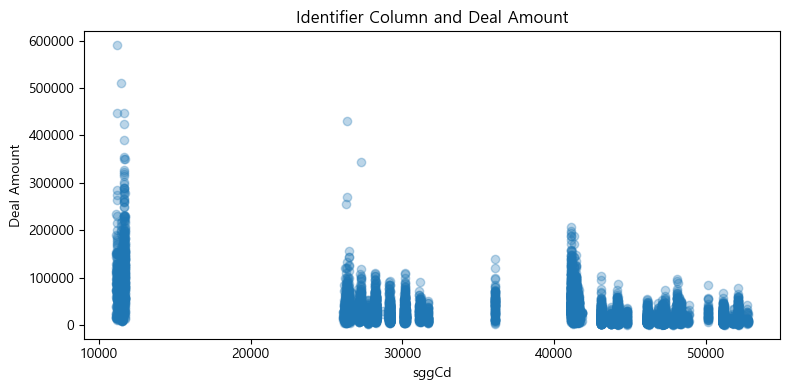

저장된 식별자 제외 컬럼:
['aptSeq', 'bonbun', 'bubun', 'jibun', 'landCd', 'roadNmBonbun', 'roadNmBubun', 'roadNmCd', 'roadNmSeq', 'roadNmSggCd', 'roadNmbCd', 'sggCd', 'umdCd', 'KOSIS_SGG_CODE', 'LEGAL_SGG_CODE', 'SGG_NM_norm', 'sggCd_norm']


In [11]:
print("=== 식별자 컬럼 자동 확인 ===")

total_rows = len(df)

id_keywords = [
    'id',
    'code',
    'cd',
    'seq',
    'no',
    'bonbun',
    'bubun',
    'jibun'
]

exclude_keywords = [
    'amount',
    'price',
    'area',
    'year',
    'month',
    'day',
    'floor',
    'age',
    'rate',
    'count',
    'avg',
    'mean',
    'sum',
    'target',
    'deal'
]

available_id_cols = []

for col in df.columns:
    col_lower = col.lower()

    has_id_keyword = False
    for keyword in id_keywords:
        if keyword in col_lower:
            has_id_keyword = True

    has_exclude_keyword = False
    for keyword in exclude_keywords:
        if keyword in col_lower:
            has_exclude_keyword = True

    if has_id_keyword and not has_exclude_keyword:
        available_id_cols.append(col)

print("자동으로 찾은 식별자 후보 컬럼:")
print(available_id_cols)

id_rows = []

for col in available_id_cols:
    unique_count = df[col].nunique(dropna=True)
    unique_ratio = unique_count / total_rows * 100

    id_rows.append({
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Unique_Count': unique_count,
        'Unique_Ratio(%)': unique_ratio,
        'Missing_Count': df[col].isna().sum()
    })

df_id = pd.DataFrame(id_rows)

if len(df_id) > 0:
    df_id = df_id.sort_values('Unique_Count', ascending=False).reset_index(drop=True)
    display(df_id.round({'Unique_Ratio(%)': 4}))
else:
    print("식별자 후보 컬럼 없음")

target_col = 'dealAmount_num'

sample_id = None

preferred_id_cols = [
    'sggCd',
    'KOSIS_SGG_CODE',
    'LEGAL_SGG_CODE',
    'umdCd'
]

for col in preferred_id_cols:
    if col in available_id_cols:
        sample_id = col
        break

if sample_id is None and len(available_id_cols) > 0:
    sample_id = available_id_cols[0]

if sample_id is not None and target_col in df.columns:
    sample_size = min(10000, len(df))
    df_sample = df.sample(n=sample_size, random_state=42)

    x_value = pd.to_numeric(df_sample[sample_id], errors='coerce')

    if x_value.isna().sum() == len(x_value):
        x_value = pd.factorize(df_sample[sample_id])[0]
        x_label = sample_id + ' encoded'
    else:
        x_label = sample_id

    plt.figure(figsize=(8, 4))
    plt.scatter(x_value, df_sample[target_col], alpha=0.3)
    plt.xlabel(x_label)
    plt.ylabel('Deal Amount')
    plt.title('Identifier Column and Deal Amount')
    plt.tight_layout()
    plt.show()

else:
    print("산점도를 그릴 수 있는 컬럼 없음")

excluded_high_card_cols = df_card['Column'].tolist()

excluded_id_cols = available_id_cols.copy()

print("저장된 식별자 제외 컬럼:")
print(excluded_id_cols)

# 9. 부가 정보 컬럼의 빈값과 정보량 확인

이 단계에서는 분석 목적과 직접 관련성이 낮거나, 비어 있는 값이 많은 부가 정보 컬럼을 확인.  

중요한 점은 단순히 `NaN`만 결측으로 보면 실제 빈값을 놓칠 수 있다는 것.  
어떤 데이터는 진짜 결측을 `NaN`으로 저장하지 않고, 빈 문자열 `""`, 공백, `-`, `None` 같은 형태로 저장하기도 함.  
그래서 이 코드에서는 `isna()`뿐만 아니라 문자열로 바꾼 뒤 공백을 제거하고, 결측처럼 보이는 값들도 함께 확인.

각 컬럼에 대해 결측 또는 빈값으로 볼 수 있는 데이터가 몇 개인지 계산.  
그리고 전체 데이터 중 몇 퍼센트인지도 같이 계산.  
또한 고유값 개수도 같이 보면서, 정보량이 충분한 컬럼인지 판단.


=== 부가 정보 컬럼의 빈값 비율 ===


,Column,Missing_or_Blank_Count,Missing_or_Blank_Ratio(%),Unique_Count
0,buyerGbn,2396830,100.0000,1
1,cdealDay,2396830,100.0000,1
2,cdealType,2396830,100.0000,1
3,slerGbn,2396830,100.0000,1
4,rgstDate,2032748,84.8099,615
5,estateAgentSggNm,1815518,75.7466,4271
6,dealingGbn,1731073,72.2234,3
7,dealDay,0,0.0000,31
8,landLeaseholdGbn,0,0.0000,2


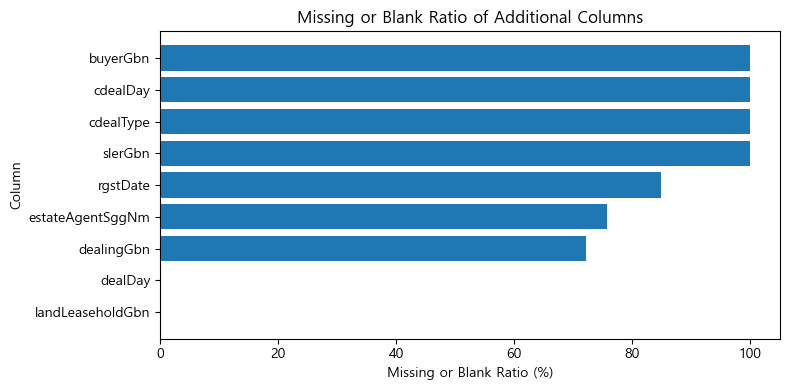

In [12]:
noisy_cols = [
    'buyerGbn', 'cdealDay', 'cdealType', 'dealDay', 'dealingGbn',
    'estateAgentSggNm', 'landLeaseholdGbn', 'rgstDate', 'slerGbn'
]

missing_rows = []

for col in noisy_cols:
    if col in df.columns:
        text_data = df[col].astype(str).str.strip()

        null_mask = df[col].isna()
        blank_mask = text_data.isin(['', '-', 'nan', 'NaN', 'None', 'none'])

        missing_like_mask = null_mask | blank_mask

        missing_count = missing_like_mask.sum()
        missing_ratio = missing_count / len(df) * 100

        missing_rows.append({
            'Column': col,
            'Missing_or_Blank_Count': missing_count,
            'Missing_or_Blank_Ratio(%)': missing_ratio,
            'Unique_Count': df[col].nunique(dropna=True)
        })

df_missing = pd.DataFrame(missing_rows)
df_missing = df_missing.sort_values('Missing_or_Blank_Ratio(%)', ascending=False).reset_index(drop=True)

print("=== 부가 정보 컬럼의 빈값 비율 ===")
display(df_missing.round({'Missing_or_Blank_Ratio(%)': 4}))

plt.figure(figsize=(8, 4))
plt.barh(df_missing['Column'], df_missing['Missing_or_Blank_Ratio(%)'])
plt.xlabel('Missing or Blank Ratio (%)')
plt.ylabel('Column')
plt.title('Missing or Blank Ratio of Additional Columns')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 11. 연도별 야간광 변수의 상관관계(다중공선성) 확인

이 단계에서는 `nl_2019`, `nl_2020`, `nl_2021`, `nl_2022`, `nl_2023`처럼 연도별로 나누어진 야간광 변수를 확인.  
야간광 데이터는 지역의 밤 밝기를 나타내는 값.  
이번 프로젝트에서는 지역의 경제 활동성이나 인프라 정도를 간접적으로 보여주는 중요한 변수로 사용할 수 있음.

하지만 같은 지역의 야간광 값은 보통 해마다 완전히 달라지지 않음.  
도시 인프라나 생활권은 짧은 기간에 급격하게 변하지 않는 경우가 많기 때문.  
그래서 여러 연도의 야간광 컬럼을 모두 넣으면 서로 매우 비슷한 정보를 반복해서 넣는 문제가 생길 수 있음.
  
그래서 원본 연도별 컬럼을 모두 사용하는 대신, 평균 야간광이나 변화량 같은 요약 변수로 바꾸는 작업을 수행.

이 코드에서는 연도별 야간광 컬럼 사이의 상관계수를 계산.  
상관계수가 1에 가까울수록 두 컬럼이 거의 비슷하게 움직인다는 뜻.  


=== 연도별 야간광 데이터 상관계수 ===


,nl_2019,nl_2020,nl_2021,nl_2022,nl_2023
nl_2019,1.0000,0.9967,0.9906,0.9883,0.9869
nl_2020,0.9967,1.0000,0.9945,0.9927,0.9910
nl_2021,0.9906,0.9945,1.0000,0.9970,0.9935
nl_2022,0.9883,0.9927,0.9970,1.0000,0.9975
nl_2023,0.9869,0.9910,0.9935,0.9975,1.0000


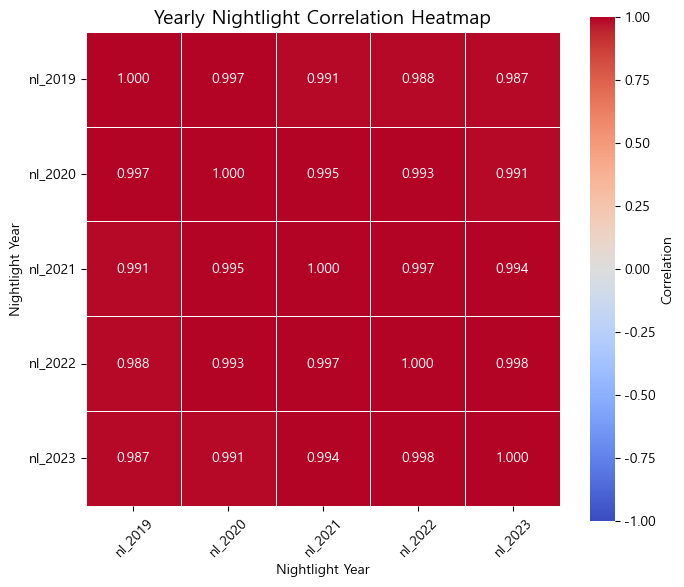

저장된 개별 연도 야간광 제외 컬럼:
['nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']


In [13]:
nl_cols = ['nl_2019', 'nl_2020', 'nl_2021', 'nl_2022', 'nl_2023']

available_nl_cols = []

for col in nl_cols:
    if col in df.columns:
        available_nl_cols.append(col)

nl_corr = df[available_nl_cols].corr()

print("=== 연도별 야간광 데이터 상관계수 ===")
display(nl_corr.round(4))
plt.figure(figsize=(7, 6))

sns.heatmap(
    nl_corr,
    annot=True,          # 칸 안에 상관계수 표시
    fmt=".3f",           # 소수점 3자리까지 표시
    cmap="coolwarm",     # 색상 구분
    vmin=-1,
    vmax=1,
    center=0,
    square=True,         # 정사각형 형태
    linewidths=0.5,      # 칸 사이 선
    cbar_kws={"label": "Correlation"}
)

plt.title("Yearly Nightlight Correlation Heatmap", fontsize=14)
plt.xlabel("Nightlight Year")
plt.ylabel("Nightlight Year")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

excluded_raw_nl_cols = []

for col in df.columns:
    if col.startswith('nl_'):
        year_part = col.replace('nl_', '')

        if year_part.isdigit():
            excluded_raw_nl_cols.append(col)

print("저장된 개별 연도 야간광 제외 컬럼:")
print(excluded_raw_nl_cols)



## 12. 결정트리와 랜덤포레스트 기반 중요 컬럼 확인

이 코드에서는 아파트 실거래가 예측에 어떤 컬럼이 중요한지 확인하기 위해 결정트리와 랜덤포레스트 모델을 사용.

=== 결정트리 / 랜덤포레스트 기반 중요 컬럼 확인 ===
불러온 제외 컬럼 개수: 31
['sggCd_norm', 'dealAmount_num', 'roadNmCd', 'nl_2023', 'bubun', 'roadNmBonbun', 'LEGAL_SGG_CODE', 'sggCd', 'SGG_NM', 'aptSeq', 'landCd', 'nl_2022', 'roadNmSeq', 'umdNm', 'nl_2021', 'SGG_NM_norm', 'jibun', 'roadNm', 'roadNmbCd', 'bonbun', 'nl_2020', 'aptNm', 'rgstDate', 'dealAmount', 'nl_2019', 'umdCd', 'roadNmBubun', 'aptDong', 'KOSIS_SGG_CODE', 'roadNmSggCd', 'estateAgentSggNm']
모델 후보 컬럼 개수: 23
['buildYear', 'buyerGbn', 'cdealDay', 'cdealType', 'dealDay', 'dealMonth', 'dealYear', 'dealingGbn', 'excluUseAr', 'floor', 'landLeaseholdGbn', 'slerGbn', 'floor_num', 'excluUseAr_num', 'cluster_name', 'nightlight_avg', '고령화율', 'sgg_count', 'SGG_level', 'apt_age', 'nl_growth_trend', 'sgg_yearly_volume', 'aging_intensity_per_nl']
타깃 결측 제거 후 데이터 개수: 2396830
숫자형 컬럼 개수: 15
['buildYear', 'dealDay', 'dealMonth', 'dealYear', 'excluUseAr', 'floor', 'floor_num', 'excluUseAr_num', 'nightlight_avg', '고령화율', 'sgg_count', 'apt_age', 'nl_growth_trend', 'sgg

,Feature,DecisionTree_Importance,RandomForest_Importance,Average_Importance
0,nightlight_avg,0.2607,0.2533,0.2570
1,sgg_count,0.1738,0.1719,0.1728
2,excluUseAr_num,0.1625,0.1377,0.1501
3,excluUseAr,0.1162,0.1359,0.1260
4,buildYear,0.0744,0.0839,0.0792
5,nl_growth_trend,0.0738,0.0661,0.0699
6,고령화율,0.0557,0.0516,0.0537
7,cluster_name_중광도,0.0274,0.0253,0.0264
8,sgg_yearly_volume,0.0172,0.0172,0.0172
9,dealYear,0.0111,0.0171,0.0141


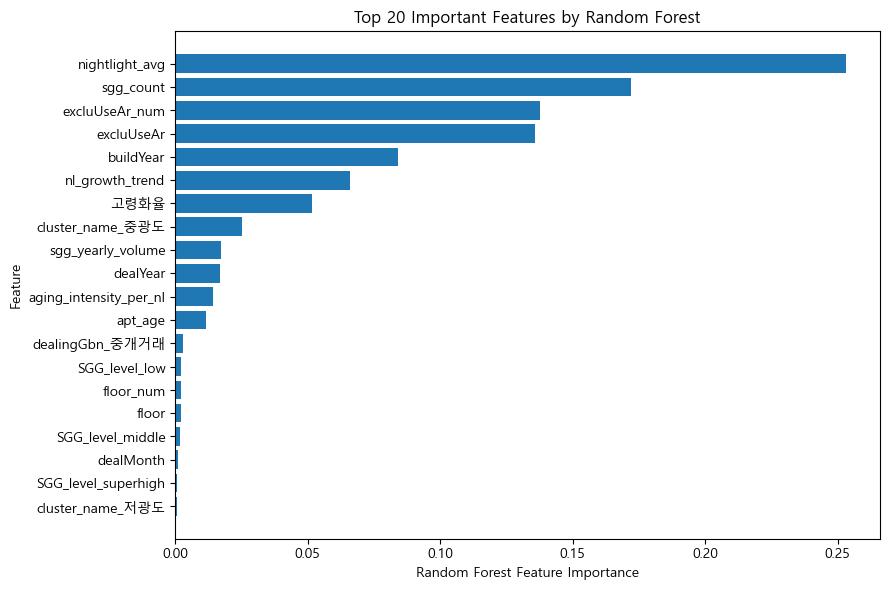

In [14]:
print("=== 결정트리 / 랜덤포레스트 기반 중요 컬럼 확인 ===")

target_col = 'dealAmount_num'

# 1. 파생 변수 생성
if 'apt_age' not in df.columns:
    if 'dealYear' in df.columns and 'buildYear' in df.columns:
        df['apt_age'] = df['dealYear'] - df['buildYear']
        df.loc[df['apt_age'] < 0, 'apt_age'] = np.nan

if 'nl_growth_trend' not in df.columns:
    if 'nl_2023' in df.columns and 'nl_2019' in df.columns:
        df['nl_growth_trend'] = df['nl_2023'] - df['nl_2019']

if 'sgg_yearly_volume' not in df.columns:
    if 'KOSIS_SGG_CODE' in df.columns and 'dealYear' in df.columns and target_col in df.columns:
        df['sgg_yearly_volume'] = df.groupby(
            ['KOSIS_SGG_CODE', 'dealYear']
        )[target_col].transform('count')

if 'aging_intensity_per_nl' not in df.columns:
    if '고령화율' in df.columns and 'nightlight_avg' in df.columns:
        nightlight_value = df['nightlight_avg'].replace(0, np.nan)
        df['aging_intensity_per_nl'] = df['고령화율'] / nightlight_value


# 2. 위 셀에서 저장한 제외 컬럼 불러오기
exclude_cols = []

if 'excluded_raw_nl_cols' in globals():
    exclude_cols += excluded_raw_nl_cols

if 'excluded_high_card_cols' in globals():
    exclude_cols += excluded_high_card_cols

if 'excluded_id_cols' in globals():
    exclude_cols += excluded_id_cols

if 'excluded_target_cols' in globals():
    exclude_cols += excluded_target_cols

# 타깃 컬럼은 무조건 제외
exclude_cols.append(target_col)

# 실제 df에 존재하는 컬럼만 남기고 중복 제거
exclude_cols = list(set([col for col in exclude_cols if col in df.columns]))

print("불러온 제외 컬럼 개수:", len(exclude_cols))
print(exclude_cols)


# 3. 제외 컬럼을 뺀 나머지를 후보 컬럼으로 사용
candidate_cols = []

for col in df.columns:
    if col not in exclude_cols:
        candidate_cols.append(col)

print("모델 후보 컬럼 개수:", len(candidate_cols))
print(candidate_cols)


# 4. 모델 학습용 데이터 만들기
model_df = df[candidate_cols + [target_col]].copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df[target_col] = pd.to_numeric(model_df[target_col], errors='coerce')
model_df = model_df.dropna(subset=[target_col])

print("타깃 결측 제거 후 데이터 개수:", len(model_df))


# 5. 숫자형 / 범주형 컬럼 분리
feature_cols = [col for col in model_df.columns if col != target_col]

numeric_cols = []
categorical_cols = []

for col in feature_cols:
    if pd.api.types.is_numeric_dtype(model_df[col]):
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print("숫자형 컬럼 개수:", len(numeric_cols))
print(numeric_cols)

print("범주형 컬럼 개수:", len(categorical_cols))
print(categorical_cols)


# 6. 숫자형 결측치는 중앙값으로 채우기
for col in numeric_cols:
    median_value = model_df[col].median()
    model_df[col] = model_df[col].fillna(median_value)

# 7. 범주형 결측치는 missing으로 채우기
for col in categorical_cols:
    model_df[col] = model_df[col].astype(str)
    model_df[col] = model_df[col].fillna('missing')


# 8. 범주형 컬럼 원-핫 인코딩
X = model_df[feature_cols]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

y = model_df[target_col]

print("최종 입력 데이터 크기:", X.shape)
print("모델 학습에 사용된 데이터 개수:", len(X))


# 9. 훈련 데이터 / 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 10. 결정트리 모델 학습
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("=== 결정트리 성능 ===")
print("MAE:", round(tree_mae, 2))
print("R2:", round(tree_r2, 4))


# 11. 랜덤포레스트 모델 학습
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== 랜덤포레스트 성능 ===")
print("MAE:", round(rf_mae, 2))
print("R2:", round(rf_r2, 4))


# 12. Feature Importance 정리
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'DecisionTree_Importance': tree_model.feature_importances_,
    'RandomForest_Importance': rf_model.feature_importances_
})

importance_df['Average_Importance'] = (
    importance_df['DecisionTree_Importance'] +
    importance_df['RandomForest_Importance']
) / 2

importance_df = importance_df.sort_values(
    'RandomForest_Importance',
    ascending=False
).reset_index(drop=True)

print("=== 결정트리 / 랜덤포레스트 중요 컬럼 요약표 ===")
display(
    importance_df.head(30).round({
        'DecisionTree_Importance': 4,
        'RandomForest_Importance': 4,
        'Average_Importance': 4
    })
)


# 13. 랜덤포레스트 기준 중요도 그래프
plot_df = importance_df.head(20)
plot_df = plot_df.sort_values('RandomForest_Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df['Feature'], plot_df['RandomForest_Importance'])
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Important Features by Random Forest')
plt.tight_layout()
plt.show()

# 13. 대표 중요 컬럼의 구간별 평균 가격 비교



=== 대표 중요 컬럼 구간별 평균 실거래가 비교 ===
=== 전용면적 구간별 요약 ===


,구간,평균_실거래가,중앙값_실거래가,데이터_수
0,소형\n60㎡ 미만,22149.04,15500.0,1013813
1,중소형\n60~85㎡ 미만,38278.83,30000.0,1087718
2,중대형\n85~135㎡ 미만,60916.72,47500.0,242266
3,대형\n135㎡ 이상,98077.66,65000.0,53033


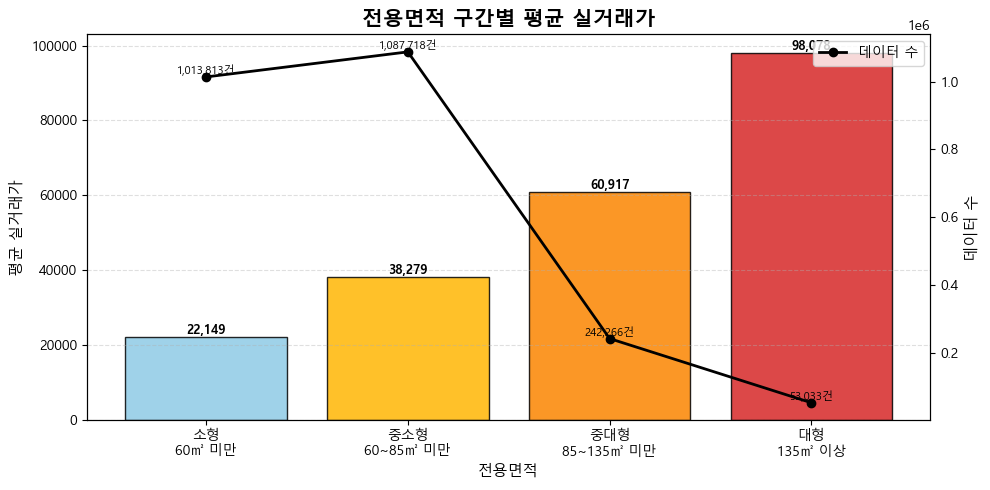

=== 아파트 연식 구간별 요약 ===


,구간,평균_실거래가,중앙값_실거래가,데이터_수
0,신축\n0~9년,43752.85,34800.0,615653
1,준신축\n10~19년,40415.33,30000.0,651162
2,구축\n20~29년,26029.29,17750.0,836923
3,노후\n30년 이상,30750.03,15600.0,292667


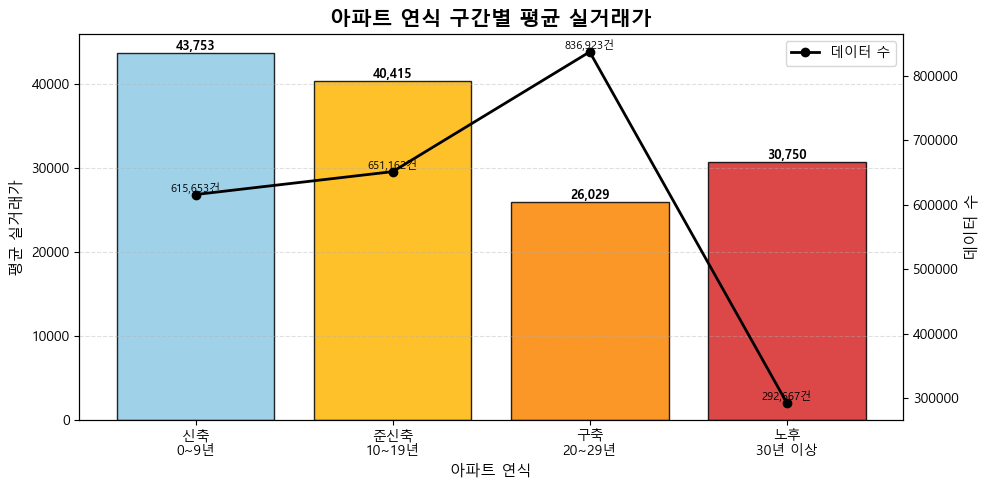

=== 고령화율 구간별 요약 ===


,구간,평균_실거래가,중앙값_실거래가,데이터_수
0,일반 지역\n7% 미만,41293.14,34000.0,6421
1,고령화 사회\n7~14% 미만,37444.41,28500.0,989093
2,고령 사회\n14~20% 미만,37549.19,26400.0,1061397
3,초고령 사회\n20% 이상,20284.90,16200.0,339919


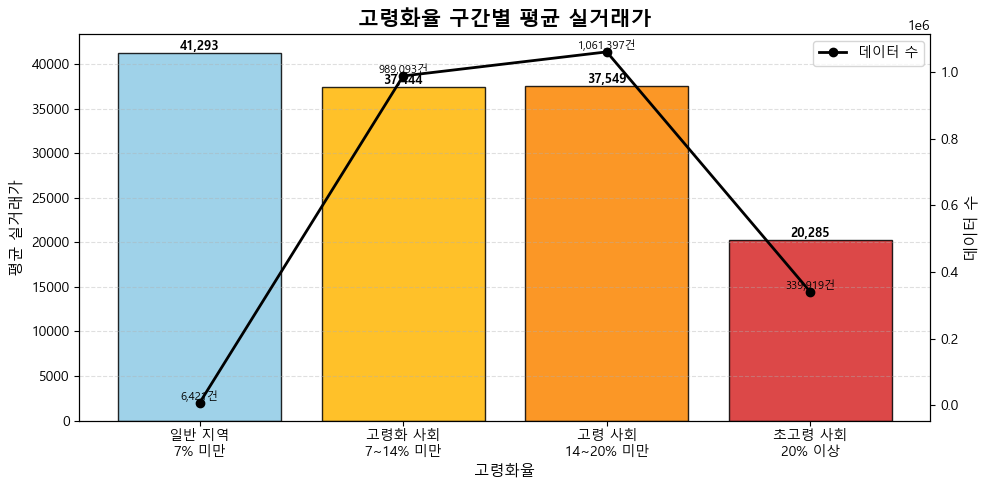

=== 평균 야간광 구간별 요약 ===


,구간,평균_실거래가,중앙값_실거래가,데이터_수
0,저광도\n10 미만,16286.68,14300.0,193721
1,중저광도\n10~30 미만,26482.30,22000.0,990201
2,중고광도\n30~60 미만,38640.18,29900.0,993215
3,고광도\n60 이상,74172.08,55000.0,219693


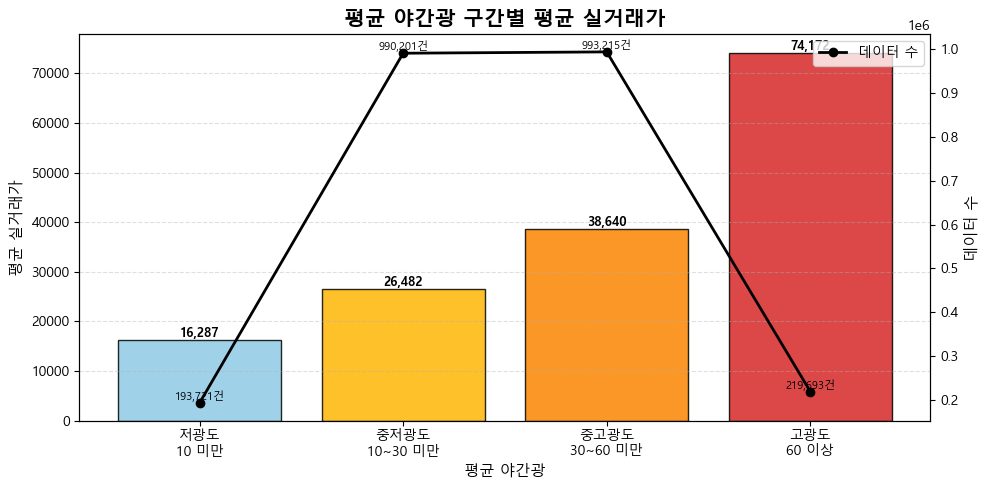

=== 야간광 대비 고령화 강도 구간별 요약 ===


,구간,평균_실거래가,중앙값_실거래가,데이터_수
0,낮음\n0.5 미만,45566.70,34000.0,1302120
1,보통\n0.5~1.0 미만,25430.67,21400.0,698783
2,높음\n1.0~2.0 미만,19592.03,16900.0,216157
3,매우 높음\n2.0 이상,15086.93,12900.0,179770


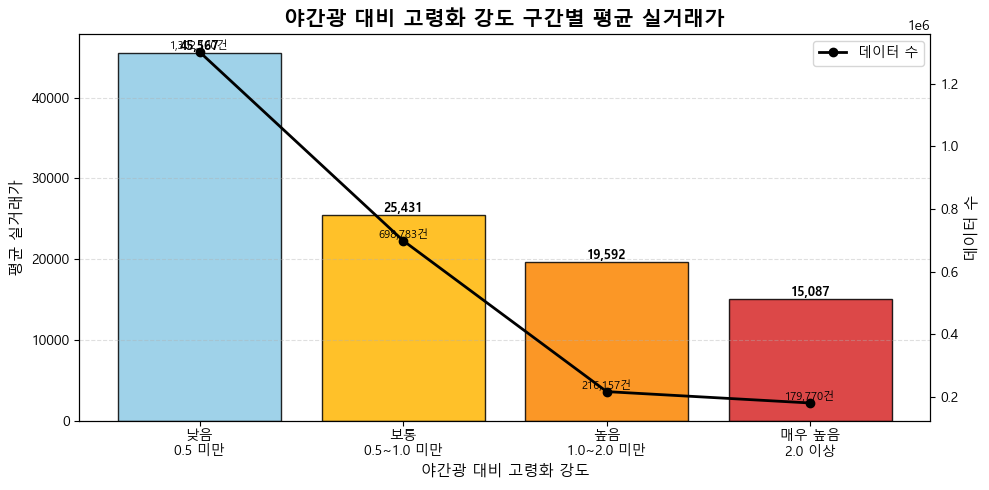

In [15]:
print("=== 대표 중요 컬럼 구간별 평균 실거래가 비교 ===")

target_col = 'dealAmount_num'

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 거래금액 숫자형 변환
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# 아파트 나이 생성
if 'apt_age' not in df.columns:
    if 'dealYear' in df.columns and 'buildYear' in df.columns:
        df['dealYear'] = pd.to_numeric(df['dealYear'], errors='coerce')
        df['buildYear'] = pd.to_numeric(df['buildYear'], errors='coerce')
        df['apt_age'] = df['dealYear'] - df['buildYear']
        df.loc[df['apt_age'] < 0, 'apt_age'] = np.nan

# 구간별 색상
bar_colors = ['#8ecae6', '#ffb703', '#fb8500', '#d62828']

# 컬럼별 구간 기준 설정
plot_settings = [
    {
        'col': 'excluUseAr_num',
        'name': '전용면적',
        'bins': [0, 60, 85, 135, np.inf],
        'labels': [
            '소형\n60㎡ 미만',
            '중소형\n60~85㎡ 미만',
            '중대형\n85~135㎡ 미만',
            '대형\n135㎡ 이상'
        ]
    },
    {
        'col': 'apt_age',
        'name': '아파트 연식',
        'bins': [0, 10, 20, 30, np.inf],
        'labels': [
            '신축\n0~9년',
            '준신축\n10~19년',
            '구축\n20~29년',
            '노후\n30년 이상'
        ]
    },
    {
        'col': '고령화율',
        'name': '고령화율',
        'bins': [-np.inf, 7, 14, 20, np.inf],
        'labels': [
            '일반 지역\n7% 미만',
            '고령화 사회\n7~14% 미만',
            '고령 사회\n14~20% 미만',
            '초고령 사회\n20% 이상'
        ]
    },
    {
        'col': 'nightlight_avg',
        'name': '평균 야간광',
        'bins': [-np.inf, 10, 30, 60, np.inf],
        'labels': [
            '저광도\n10 미만',
            '중저광도\n10~30 미만',
            '중고광도\n30~60 미만',
            '고광도\n60 이상'
        ]
    },
    {
        'col': 'aging_intensity_per_nl',
        'name': '야간광 대비 고령화 강도',
        'bins': [-np.inf, 0.5, 1.0, 2.0, np.inf],
        'labels': [
            '낮음\n0.5 미만',
            '보통\n0.5~1.0 미만',
            '높음\n1.0~2.0 미만',
            '매우 높음\n2.0 이상'
        ]
    }
]


for setting in plot_settings:
    col = setting['col']

    if col not in df.columns:
        print(col, "컬럼이 없어 건너뜀")
        continue

    temp = df[[col, target_col]].copy()

    temp[col] = pd.to_numeric(temp[col], errors='coerce')
    temp[target_col] = pd.to_numeric(temp[target_col], errors='coerce')

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()


    # 정해둔 기준으로 구간 나누기
    temp['구간'] = pd.cut(
        temp[col],
        bins=setting['bins'],
        labels=setting['labels'],
        right=False,
        include_lowest=True
    )

    temp = temp.dropna(subset=['구간'])

    # 구간별 평균, 중앙값, 데이터 수 계산
    grouped = temp.groupby('구간', observed=False)[target_col].agg(
        평균_실거래가='mean',
        중앙값_실거래가='median',
        데이터_수='count'
    ).reset_index()

    print("===", setting['name'], "구간별 요약 ===")
    display(
        grouped.round({
            '평균_실거래가': 2,
            '중앙값_실거래가': 2
        })
    )

    # 차트용 데이터
    x = np.arange(len(grouped))
    mean_values = grouped['평균_실거래가'].fillna(0)
    count_values = grouped['데이터_수'].fillna(0)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # 평균 실거래가 막대그래프
    bars = ax1.bar(
        x,
        mean_values,
        color=bar_colors[:len(grouped)],
        edgecolor='black',
        alpha=0.85
    )

    ax1.set_title(
        setting['name'] + ' 구간별 평균 실거래가',
        fontsize=15,
        fontweight='bold'
    )
    ax1.set_xlabel(setting['name'], fontsize=11)
    ax1.set_ylabel('평균 실거래가', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels(grouped['구간'].astype(str), fontsize=10)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

    # 막대 위 평균 가격 표시
    for i, value in enumerate(mean_values):
        if value > 0:
            ax1.text(
                i,
                value,
                f'{value:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    # 오른쪽 축: 데이터 수
    ax2 = ax1.twinx()

    ax2.plot(
        x,
        count_values,
        color='black',
        marker='o',
        linewidth=2,
        label='데이터 수'
    )

    ax2.set_ylabel('데이터 수', fontsize=11)

    # 데이터 수 표시
    for i, value in enumerate(count_values):
        ax2.text(
            i,
            value,
            f'{int(value):,}건',
            ha='center',
            va='bottom',
            fontsize=8,
            color='black'
        )

    # 범례
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

=== apt_raw_2019_2023 원본 데이터 기반 결정트리 / 랜덤포레스트 모델 ===
원본 데이터 크기: (2020780, 34)


,aptDong,aptNm,aptSeq,bonbun,bubun,buildYear,buyerGbn,cdealDay,cdealType,dealAmount,...,roadNmCd,roadNmSeq,roadNmSggCd,roadNmbCd,sggCd,slerGbn,umdCd,umdNm,KOSIS_SGG_CODE,LEGAL_SGG_CODE
0,,경희궁자이(2단지),11110-2445,199,0,2017,,,,"170,000",...,4100192,1,11110,,11110,,17900,홍파동,11010,11110
1,,크래스빌,11110-101,46,1,2003,,,,"90,000",...,4100499,1,11110,0,11110,,18300,평창동,11010,11110
2,,삼성,11110-73,596,0,1998,,,,"59,000",...,3100023,1,11110,0,11110,,18300,평창동,11010,11110
3,,동대문,11110-30,328,17,1966,,,,"42,000",...,3005007,1,11110,0,11110,,17400,창신동,11010,11110
4,,창신쌍용2,11110-91,703,0,1993,,,,"58,500",...,4100020,2,11110,0,11110,,17400,창신동,11010,11110


실거래가 숫자 변환 후 결측치 개수: 0
사용할 후보 컬럼 개수: 34
['aptDong', 'aptNm', 'aptSeq', 'bonbun', 'bubun', 'buildYear', 'buyerGbn', 'cdealDay', 'cdealType', 'dealDay', 'dealMonth', 'dealYear', 'dealingGbn', 'estateAgentSggNm', 'excluUseAr', 'floor', 'jibun', 'landCd', 'landLeaseholdGbn', 'rgstDate', 'roadNm', 'roadNmBonbun', 'roadNmBubun', 'roadNmCd', 'roadNmSeq', 'roadNmSggCd', 'roadNmbCd', 'sggCd', 'slerGbn', 'umdCd', 'umdNm', 'KOSIS_SGG_CODE', 'LEGAL_SGG_CODE', 'apt_age']
정답 결측 제거 후 X 크기: (2020780, 34)
정답 결측 제거 후 y 크기: (2020780,)
최종 입력 데이터 크기: (2020780, 34)
최종 타깃 데이터 크기: (2020780,)
실제 모델 학습에 사용한 데이터 개수: 300000
훈련 데이터 크기: (240000, 34)
테스트 데이터 크기: (60000, 34)
=== 결정트리 성능 ===
MAE: 9144.78
R2: 0.8318
=== 랜덤포레스트 성능 ===
MAE: 7071.91
R2: 0.9014
=== apt_raw_2019_2023 원본 데이터 기반 중요도 Top 30 ===


,Feature,DecisionTree_Importance,RandomForest_Importance,Average_Importance
0,aptSeq,0.3694,0.3474,0.3584
1,excluUseAr,0.2672,0.2574,0.2623
2,umdNm,0.1463,0.1425,0.1444
3,buildYear,0.0601,0.0564,0.0583
4,dealYear,0.0276,0.0266,0.0271
5,aptNm,0.0162,0.0249,0.0205
6,bonbun,0.0211,0.0199,0.0205
7,umdCd,0.0214,0.0199,0.0206
8,LEGAL_SGG_CODE,0.0212,0.0110,0.0161
9,KOSIS_SGG_CODE,0.0063,0.0107,0.0085


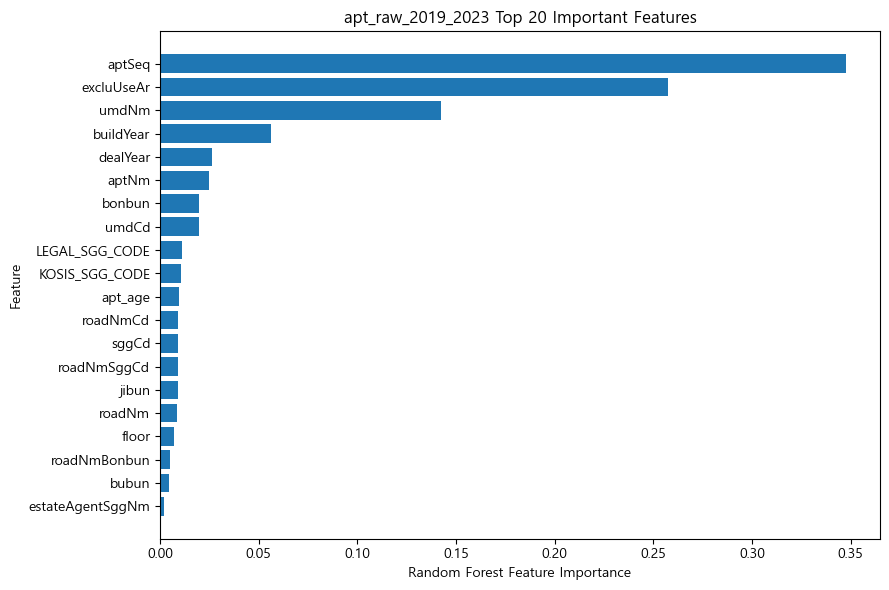

In [17]:
print("=== apt_raw_2019_2023 원본 데이터 기반 결정트리 / 랜덤포레스트 모델 ===")

# 1. apt_raw_2019_2023 데이터 불러오기
df_raw = pd.read_csv(
    'apt_raw_2019_2023.csv',
    encoding='utf-8-sig',
    low_memory=False
)

print("원본 데이터 크기:", df_raw.shape)
display(df_raw.head())


# 2. 정답 컬럼 만들기
target_col = 'dealAmount_num'

df_raw[target_col] = (
    df_raw['dealAmount']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df_raw[target_col] = pd.to_numeric(df_raw[target_col], errors='coerce')

print("실거래가 숫자 변환 후 결측치 개수:", df_raw[target_col].isna().sum())


# 3. 아파트 나이 컬럼 만들기
# apt_raw 안에 있는 dealYear, buildYear만 사용해서 만든 파생 변수
if 'dealYear' in df_raw.columns and 'buildYear' in df_raw.columns:
    df_raw['dealYear'] = pd.to_numeric(df_raw['dealYear'], errors='coerce')
    df_raw['buildYear'] = pd.to_numeric(df_raw['buildYear'], errors='coerce')

    df_raw['apt_age'] = df_raw['dealYear'] - df_raw['buildYear']
    df_raw.loc[df_raw['apt_age'] < 0, 'apt_age'] = np.nan


# 4. apt_raw 원본 컬럼 중에서 모델에 사용할 컬럼 정하기
# dealAmount는 정답이므로 제외
exclude_cols = [
    'dealAmount',
    'dealAmount_num'
]

feature_cols = []

for col in df_raw.columns:
    if col not in exclude_cols:
        feature_cols.append(col)

print("사용할 후보 컬럼 개수:", len(feature_cols))
print(feature_cols)


# 5. 모델 입력 데이터 X 만들기
X = pd.DataFrame(index=df_raw.index)

for col in feature_cols:
    temp = df_raw[col]

    # 숫자형 컬럼이면 그대로 사용
    if pd.api.types.is_numeric_dtype(temp):
        X[col] = pd.to_numeric(temp, errors='coerce')

    # 문자형 컬럼이면 처리
    else:
        temp_str = temp.astype(str).str.replace(',', '', regex=False).str.strip()
        temp_num = pd.to_numeric(temp_str, errors='coerce')

        original_not_null = temp.notna().sum()
        converted_not_null = temp_num.notna().sum()

        # 문자처럼 보이지만 대부분 숫자로 바뀌는 컬럼은 숫자로 사용
        if original_not_null > 0 and converted_not_null / original_not_null >= 0.8:
            X[col] = temp_num

        # 진짜 문자형 컬럼은 코드값으로 변환
        else:
            temp_cat = temp.astype('string').fillna('missing')
            X[col] = pd.factorize(temp_cat)[0]


# 6. 정답 데이터 y 만들기
y = df_raw[target_col]


# 7. 정답이 없는 행 제거
valid_index = y.dropna().index

X = X.loc[valid_index]
y = y.loc[valid_index]

print("정답 결측 제거 후 X 크기:", X.shape)
print("정답 결측 제거 후 y 크기:", y.shape)


# 8. 무한대 값 처리
X = X.replace([np.inf, -np.inf], np.nan)


# 9. 입력 컬럼 결측치 처리
for col in X.columns:
    median_value = X[col].median()

    if pd.isna(median_value):
        X[col] = X[col].fillna(0)
    else:
        X[col] = X[col].fillna(median_value)

print("최종 입력 데이터 크기:", X.shape)
print("최종 타깃 데이터 크기:", y.shape)


# 10. 데이터가 너무 크면 일부만 샘플링
# 전체를 쓰고 싶으면 sample_size를 len(X)로 바꾸면 됨
sample_size = min(300000, len(X))

if len(X) > sample_size:
    sample_index = X.sample(n=sample_size, random_state=42).index
    X_model = X.loc[sample_index]
    y_model = y.loc[sample_index]
else:
    X_model = X
    y_model = y

print("실제 모델 학습에 사용한 데이터 개수:", len(X_model))


# 11. 훈련 데이터 / 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42
)

print("훈련 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)


# 12. 결정트리 모델 학습
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("=== 결정트리 성능 ===")
print("MAE:", round(tree_mae, 2))
print("R2:", round(tree_r2, 4))


# 13. 랜덤포레스트 모델 학습
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=== 랜덤포레스트 성능 ===")
print("MAE:", round(rf_mae, 2))
print("R2:", round(rf_r2, 4))


# 14. Feature Importance 정리
importance_df = pd.DataFrame({
    'Feature': X_model.columns,
    'DecisionTree_Importance': tree_model.feature_importances_,
    'RandomForest_Importance': rf_model.feature_importances_
})

importance_df['Average_Importance'] = (
    importance_df['DecisionTree_Importance'] +
    importance_df['RandomForest_Importance']
) / 2

importance_df = importance_df.sort_values(
    'RandomForest_Importance',
    ascending=False
).reset_index(drop=True)

print("=== apt_raw_2019_2023 원본 데이터 기반 중요도 Top 30 ===")
display(
    importance_df.head(30).round({
        'DecisionTree_Importance': 4,
        'RandomForest_Importance': 4,
        'Average_Importance': 4
    })
)


# 15. 중요도 그래프
plot_df = importance_df.head(20)
plot_df = plot_df.sort_values('RandomForest_Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df['Feature'], plot_df['RandomForest_Importance'])
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Feature')
plt.title('apt_raw_2019_2023 Top 20 Important Features')
plt.tight_layout()
plt.show()